In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay, 
                             classification_report,precision_score, 
                             recall_score, f1_score)

## load dataset

In [2]:
data=pd.read_csv('creditcard_2023.csv')

### take 10 features and 5000 samples

In [3]:
cols =[f"V{i}" for i in range(1,11)]+["Class"]
df=data[cols].sample(n=5000,random_state=42)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
437378,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,-0.673283,1
504222,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,-0.651518,1
4794,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,0.414358,0
388411,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.466586,-1.045508,-1.234377,1
424512,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,-0.370119,1
...,...,...,...,...,...,...,...,...,...,...,...
526914,-0.925360,0.574154,-0.655923,0.649058,0.220060,-0.291297,-0.432656,-0.680372,0.119131,-0.224186,1
521485,0.736535,0.408469,-0.496347,0.859202,1.943864,-0.798219,1.049960,-0.350846,-0.672882,-0.089856,1
344760,-1.161336,0.528310,-1.169483,0.998217,-0.798066,-1.380016,-0.952326,0.827751,-1.403277,-1.261158,1
53149,-0.063963,-0.060938,1.370899,-0.500025,0.303374,0.039773,0.799427,-0.291859,0.347868,0.814980,0


### check for null values

In [4]:
df.isnull().sum()

V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
Class    0
dtype: int64

### detect and remove duplicated rows

In [5]:
df.duplicated().sum()

np.int64(53)

In [6]:
df=df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

### detect and handle Outliers

In [8]:
cols_to_clean=[f"V{i}" for i in range(1,11)]
for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers in {col}:")
    print("Count:", outliers.shape[0])
    print("-" * 40)

Outliers in V1:
Count: 0
----------------------------------------
Outliers in V2:
Count: 350
----------------------------------------
Outliers in V3:
Count: 49
----------------------------------------
Outliers in V4:
Count: 25
----------------------------------------
Outliers in V5:
Count: 607
----------------------------------------
Outliers in V6:
Count: 385
----------------------------------------
Outliers in V7:
Count: 473
----------------------------------------
Outliers in V8:
Count: 782
----------------------------------------
Outliers in V9:
Count: 140
----------------------------------------
Outliers in V10:
Count: 96
----------------------------------------


In [9]:
for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    df[col] = df[col].clip(lower, upper)



In [10]:
for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers in {col}:")
    print("Count:", outliers.shape[0])
    print("-" * 40)

Outliers in V1:
Count: 0
----------------------------------------
Outliers in V2:
Count: 0
----------------------------------------
Outliers in V3:
Count: 0
----------------------------------------
Outliers in V4:
Count: 0
----------------------------------------
Outliers in V5:
Count: 0
----------------------------------------
Outliers in V6:
Count: 0
----------------------------------------
Outliers in V7:
Count: 0
----------------------------------------
Outliers in V8:
Count: 0
----------------------------------------
Outliers in V9:
Count: 0
----------------------------------------
Outliers in V10:
Count: 0
----------------------------------------


# PCA

In [11]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
437378,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,-0.673283,1
504222,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,-0.651518,1
4794,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,0.414358,0
388411,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.392280,-1.045508,-1.234377,1
424512,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,-0.370119,1


 - ​Standardization is necessary because PCA is a variance-maximizing method.
 - Without it, features with larger numerical ranges will dominate the principal components regardless of their actual importance.
 - By scaling all features to have mean=0 and standard deviation=1, we ensure that each feature contributes equally to the analysis, making the result independent of the units of measurement.

In [12]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std
X_scaled = standardize(df[cols_to_clean].values)
X_scaled

array([[ 0.39775859, -0.0048563 , -0.60266306, ...,  0.67737583,
         0.07412373, -0.75976028],
       [-0.27479114,  0.44500587, -0.40174457, ...,  0.84058563,
        -0.65291971, -0.73546329],
       [-0.15122954, -0.11380098,  2.18103676, ..., -0.79942709,
         1.33634013,  0.45441184],
       ...,
       [-1.21556128,  0.83359105, -1.22155163, ...,  1.96183023,
        -1.53440878, -1.41602531],
       [-0.09632407,  0.00811026,  1.39785377, ..., -1.00552596,
         0.3674254 ,  0.90164015],
       [ 0.01662212,  0.90491583, -0.77640586, ...,  0.25673231,
        -1.18824562, -0.60138227]], shape=(4947, 10))

### PCA implementatin steps:

-  Mean Centering (fit): 
  Calculates the mean of each feature and subtracts it from the data (X - \mu). This centers the dataset around 
  the origin, which is a prerequisite for covariance calculation.

- ​Covariance Matrix Calculation:
  Computes the covariance matrix to understand how the dimensions vary together and identify correlations between features.
  
- ​Eigen-Decomposition:
  Uses np.linalg.eig to find:
  - Eigenvalues: Represent the magnitude of variance captured by each axis.
  - ​Eigenvectors: Represent the direction of the new principal components.

- ​Sorting & Selection:
 Sorts the eigenvectors based on their corresponding eigenvalues in descending order. We then select the top k components (where k = n_components) that capture the most variance.
- ​Dimensionality Reduction (transform):
 Projects the original centered data onto the selected principal components using a dot product. This results in a new, lower-dimensional representation of the data.
- ​Variance Analysis:
 Calculates the Explained Variance Ratio to quantify the percentage of information (variance) retained in the reduced feature space.

In [13]:
class PCA_manual():
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.eigenvalues = None 
        self.explained_variance_ratio = None

    def fit(self, X):

        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
 
        cov = np.cov(X_centered, rowvar=False)
        
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        
        eigenvectors = eigenvectors.T
        idxs = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]
        
        total_var = np.sum(self.eigenvalues)
        self.explained_variance_ratio = (self.eigenvalues / total_var)[:self.n_components]
        
        self.components = eigenvectors[0:self.n_components]

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components.T)

    def fit_transform(self,X): 
        self.fit(X)
        return self.transform(X)   

manual_model = PCA_manual(n_components=2)
X_manual_result = manual_model.fit_transform(X_scaled)
X_manual_result

array([[-0.67284365, -0.30639234],
       [-1.37216924, -0.32878594],
       [ 2.18615621, -0.33593938],
       ...,
       [-4.20313435, -0.57336077],
       [ 1.78105075,  0.17524554],
       [-1.43792706,  2.01939175]], shape=(4947, 2))

- ### Scree Plot Analysis
Observations:

​PC1 (First Component): Explains the majority of the variance (approx. 63%), capturing the primary patterns of the dataset.

​PC2 (Second Component): Explains a much smaller portion (approx. 8%), representing secondary information.

​Total Variance: Together, the first two components account for about 71% of the total information.


​Conclusion: Projecting the data onto these 2 PCs is sufficient for a 2D visualization as they retain the most significant structural variance while reducing dimensionality.

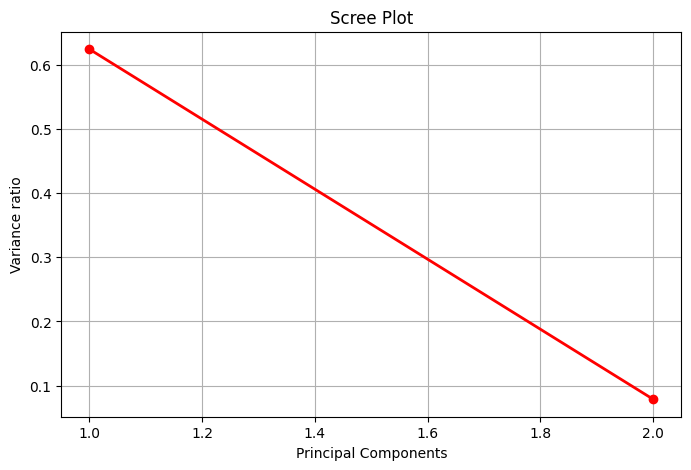

In [14]:
plt.figure(figsize=(8, 5))
 
plt.plot(range(1, len(manual_model.explained_variance_ratio) + 1), 
         manual_model.explained_variance_ratio, 'ro-', linewidth=2)

plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance ratio') 
plt.grid(True)
plt.show()

### PCA projection plot
After reducing the dataset's dimensionality, we utilize this scatter plot to evaluate the performance of Manual PCA implementation.

​Projection Logic: The plot maps the high-dimensional samples onto a 2D plane defined by the two axes of maximum variance (PC1 and PC2) and colored by class labels

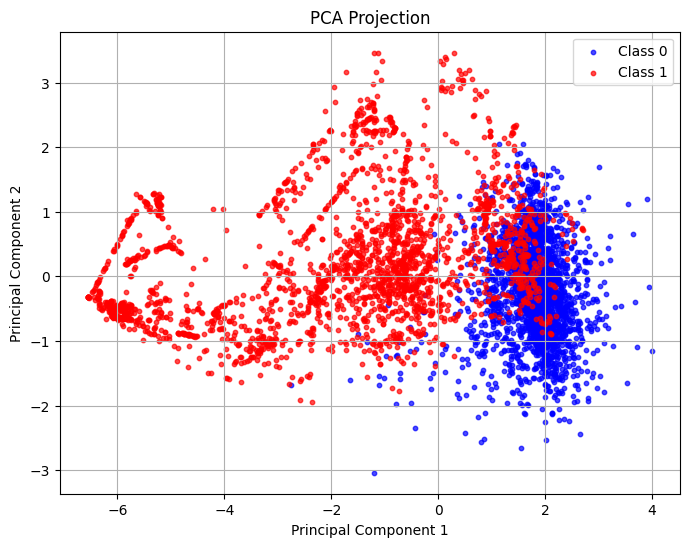

In [15]:
def plot_pca_projection(X_pca, y, title):
    plt.figure(figsize=(8, 6))
    colors = ['Blue', 'Red']
    unique_labels = np.unique(y)
    for label in unique_labels:
        plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=f'Class {label}', c=colors[label],alpha=0.7,s=10)
    
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_pca_projection(X_manual_result, df['Class'], "PCA Projection")

## Maneual PCA vs sklearn PCA (numerical comparison)

In [16]:
sk_model = PCA(n_components=2)
X_sk_result = sk_model.fit_transform(X_scaled)

comparison = pd.DataFrame({
    'Manual_PC1': X_manual_result[:10, 0],
    'Manual_PC2': X_manual_result[:10, 1],
    'Sklearn_PC1': X_sk_result[:10, 0],
    'Sklearn_PC2': X_sk_result[:10, 1]
})
 
print(f"\nManual Variance Ratio: {manual_model.explained_variance_ratio}")
print(f"Sklearn Variance Ratio: {sk_model.explained_variance_ratio_}")
comparison


Manual Variance Ratio: [0.62438539 0.0788559 ]
Sklearn Variance Ratio: [0.62438539 0.0788559 ]


,Manual_PC1,Manual_PC2,Sklearn_PC1,Sklearn_PC2
0,-0.672844,-0.306392,-0.672844,-0.306392
1,-1.372169,-0.328786,-1.372169,-0.328786
2,2.186156,-0.335939,2.186156,-0.335939
3,-3.142778,-1.071977,-3.142778,-1.071977
4,-1.005413,-0.093084,-1.005413,-0.093084
5,2.013084,-0.513601,2.013084,-0.513601
6,-5.436972,-0.431893,-5.436972,-0.431893
7,-0.430218,0.204159,-0.430218,0.204159
8,1.060401,-0.231046,1.060401,-0.231046
9,-5.259830,1.135505,-5.259830,1.135505


## Maneual PCA vs sklearn PCA (visual comparison)

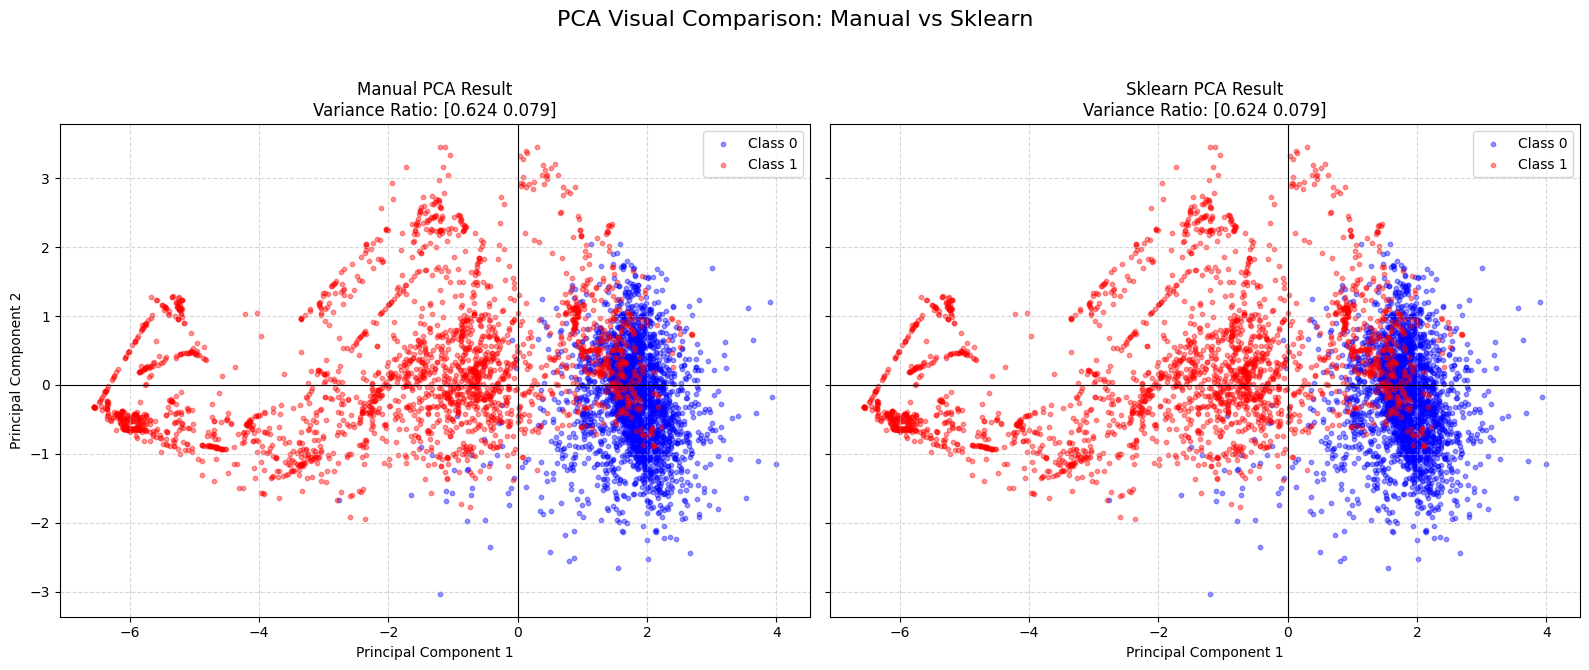

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('PCA Visual Comparison: Manual vs Sklearn', fontsize=16)

dot_size = 10     
dot_alpha = 0.4    
colors = ['Blue', 'Red']

unique_labels = np.unique(df['Class'])
for i, label in enumerate(unique_labels):
    mask = (df['Class'] == label)
    ax1.scatter(X_manual_result[mask, 0], X_manual_result[mask, 1], 
                s=dot_size, alpha=dot_alpha, color=colors[i], label=f'Class {label}')


ax1.set_title(f'Manual PCA Result\nVariance Ratio: {manual_model.explained_variance_ratio.round(3)}')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=0.8) 
ax1.axvline(0, color='black', linewidth=0.8)
ax1.legend()


for i, label in enumerate(unique_labels):
    mask = (df['Class'] == label)
    ax2.scatter(X_sk_result[mask, 0], X_sk_result[mask, 1], 
                s=dot_size, alpha=dot_alpha, color=colors[i], label=f'Class {label}')


ax2.set_title(f'Sklearn PCA Result\nVariance Ratio: {sk_model.explained_variance_ratio_.round(3)}')
ax2.set_xlabel('Principal Component 1')

ax2.grid(True, linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.legend()


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# Separate Features and Labels for classification

The dataset is divided into:
- X → input features
- y → target labels

The target column "Class" contains:
- 0 → Non-Fraud
- 1 → Fraud

In [18]:
x =df[cols_to_clean].values
# label (target)
y= df['Class'].values    
y = np.where(y == 0, -1, 1)

### split the data into train and test manualy

In [19]:
# split data train , test manual
np.random.seed(42)
indices = np.arange(len(x))
np.random.shuffle(indices)
x= x[indices]
y = y[indices]
# Split ratio
split_index = int(0.8 * len(x))
X_train = x[:split_index]
X_test = x[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

In [20]:
X_train = standardize(X_train)
X_test = standardize(X_test)
X_train

array([[-7.17876208e-01, -9.77983253e-01,  1.18744358e+00, ...,
         9.02562131e-01,  4.95430809e-01, -1.91525630e-03],
       [-8.41568188e-02, -8.62516317e-01,  4.25898073e-01, ...,
        -5.73960881e-01,  6.37477300e-01,  4.48858998e-01],
       [ 1.15343645e-01,  1.14998599e+00, -9.14635531e-01, ...,
         4.54805929e-01, -1.28935825e+00, -7.56744675e-01],
       ...,
       [-1.68773402e+00,  2.26968447e+00, -1.78993498e+00, ...,
         1.97275015e+00, -1.50150809e+00, -2.58414566e+00],
       [ 9.14648549e-02, -1.63335035e-01,  4.78905385e-01, ...,
        -1.20078021e+00,  1.04558878e+00,  9.66033598e-01],
       [ 1.28079508e+00, -9.26858877e-01,  3.48081423e-01, ...,
        -3.01172868e-01,  1.01066994e+00,  8.19679905e-01]],
      shape=(3957, 10))

# LDA

Linear Discriminant Analysis is a feature
extraction technique is used to find a direction that best separates classes by maximizing between-class distance and minimizing within-class spread

In [21]:
class LDA:
    def __init__(self, n_components=None):
        self.W = None
        self.n_components = n_components # number of dimensions after projection

    def fit(self, X, y):
        n_features = X.shape[1]
        classes = np.unique(y)

        mean_overall = np.mean(X, axis=0) #mean of all samples

        Sw = np.zeros((n_features, n_features))
        Sb = np.zeros((n_features, n_features))

        for c in classes:
            Xc = X[y == c]
            mean_c = np.mean(Xc, axis=0)

            Sw += (Xc - mean_c).T @ (Xc - mean_c)

            n_c = Xc.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
            Sb += n_c * (mean_diff @ mean_diff.T)

        A = np.linalg.pinv(Sw) @ Sb # compute Sw^-1 * Sb

        eig_vals, eig_vecs = np.linalg.eig(A)

        idx = np.argsort(eig_vals)[::-1]
        eig_vecs = eig_vecs[:, idx]

        if self.n_components is None:
            self.n_components = len(classes) - 1

        self.W = eig_vecs[:, :self.n_components].real # Select top components → projection matrix W

    def transform(self, X):
        return X @ self.W # Project data onto LDA directions

# Number of LDA Components

LDA can produce a maximum of (C−1) components,
where C is the number of classes.

Since the dataset contains:
- Fraud
- Non-Fraud

There are 2 classes, so:

Components = 2 − 1 = 1

In [22]:
print(f"Number of unique classes: {len(np.unique(y_test))}")

Number of unique classes: 2


# Apply LDA Projection

The training data is used to learn the optimal discriminant directions.

The data is then projected onto the new LDA feature space.

In [23]:
lda_scratch = LDA(n_components=1)

lda_scratch.fit(X_train, y_train)

X_train_lda = lda_scratch.transform(X_train)

X_test_lda = lda_scratch.transform(X_test)

# Compute Class Means

The mean vector of each class is computed in the projected LDA space.

These means will later be used for nearest mean classification.

# Nearest Mean Classification

Each test sample is classified based on the nearest class mean
using Euclidean distance.

The sample is assigned to the class with the minimum distance.

In [24]:
class_means = {}

for c in np.unique(y_train):

    class_means[c] = np.mean(
        X_train_lda[y_train == c],
        axis=0
    )

In [25]:
predictions = []

for sample in X_test_lda:

    distances = []

    for c in class_means:

        distance = np.linalg.norm(
            sample - class_means[c]
        )

        distances.append(distance)

    predicted_class = list(class_means.keys())[
        np.argmin(distances)
    ]

    predictions.append(predicted_class)

predictions = np.array(predictions)

# Display Predicted vs Actual Classes

The first few predictions are displayed to compare:
- predicted labels
- actual labels

This helps verify that the classifier is working correctly.

In [26]:
for i in range(10):

    print("Actual:", y_test[i],
          "Predicted:", predictions[i])

Actual: -1 Predicted: -1
Actual: -1 Predicted: -1
Actual: -1 Predicted: -1
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: -1 Predicted: -1
Actual: -1 Predicted: -1
Actual: -1 Predicted: -1
Actual: 1 Predicted: 1


# Classification Accuracy

Accuracy measures the percentage of correctly classified samples.

It is computed as:

Accuracy = Correct Predictions / Total Predictions

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("From Scratch Accuracy:", accuracy)

From Scratch Accuracy: 0.906060606060606


# Confusion Matrix

The confusion matrix summarizes classification performance.

It shows:
- correctly classified samples
- incorrectly classified samples
- false positives
- false negatives

In [28]:

cm = confusion_matrix(y_test, predictions)
print(cm)

[[474  11]
 [ 82 423]]


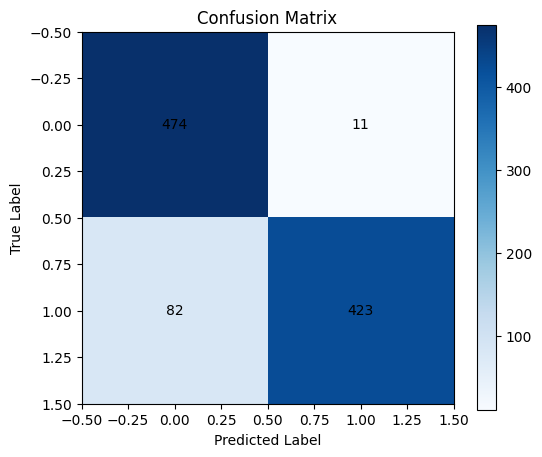

In [29]:
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.show()

# Scikit-Learn LDA Comparison

The same dataset is evaluated using sklearn's built-in
LinearDiscriminantAnalysis implementation.

This serves as a benchmark to validate the custom implementation.

In [30]:

lda_sklearn = LinearDiscriminantAnalysis(n_components=1)

lda_sklearn.fit(X_train, y_train)

X_train_sklearn = lda_sklearn.transform(X_train)

sklearn_predictions = lda_sklearn.predict(X_test)

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_predictions
)

print("Sklearn Accuracy:", sklearn_accuracy)

Sklearn Accuracy: 0.9050505050505051


# Confusion Matrix

In [31]:
cm_sklearn = confusion_matrix(
    y_test,
    sklearn_predictions
)

print(cm_sklearn)

[[474  11]
 [ 83 422]]


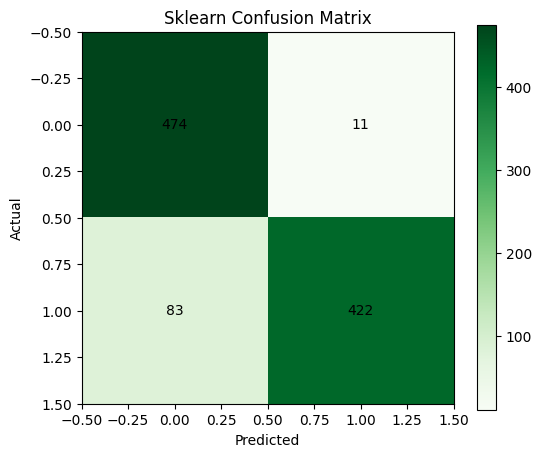

In [32]:
plt.figure(figsize=(6,5))

plt.imshow(cm_sklearn, cmap='Greens')

plt.title("Sklearn Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

for i in range(len(cm_sklearn)):
    for j in range(len(cm_sklearn)):
        plt.text(j, i, cm_sklearn[i, j],
                 ha='center',
                 va='center')

plt.show()

# LDA Projection Visualization

The projected data is visualized in the LDA space.

Because the dataset contains only 2 classes,
LDA produces only one discriminant component (LD1).

The visualization helps show class separation after projection.

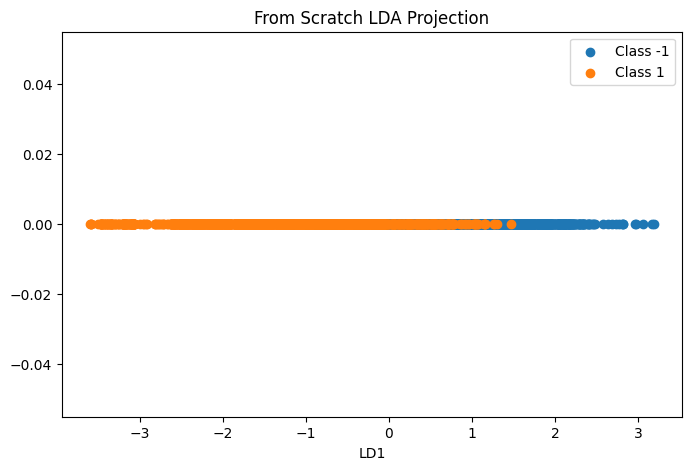

In [33]:
plt.figure(figsize=(8,5))

for c in np.unique(y_train):

    plt.scatter(
        X_train_lda[y_train == c],
        np.zeros_like(X_train_lda[y_train == c]),
        label=f"Class {c}"
    )

plt.xlabel("LD1")

plt.title("From Scratch LDA Projection")

plt.legend()

plt.show()

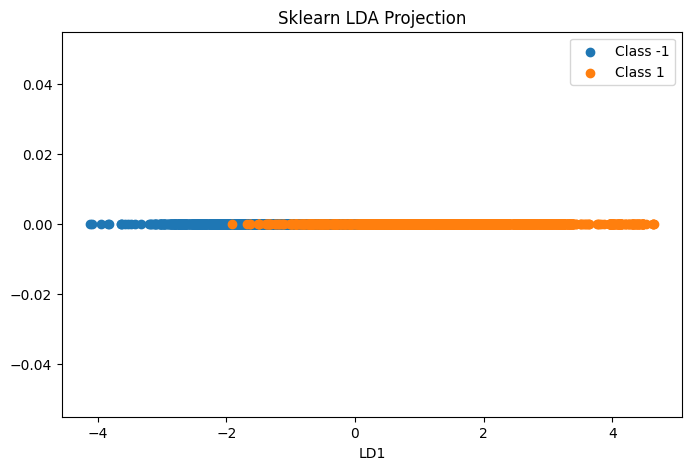

In [34]:
plt.figure(figsize=(8,5))

for c in np.unique(y_train):

    plt.scatter(
        X_train_sklearn[y_train == c],
        np.zeros_like(X_train_sklearn[y_train == c]),
        label=f"Class {c}"
    )

plt.xlabel("LD1")

plt.title("Sklearn LDA Projection")

plt.legend()

plt.show()

# SVM

### Kernel Choice Justification

The RBF (Gaussian) kernel was selected because the dataset have nonlinear relationships between features and target classes.  
RBF is effective in handling complex decision boundaries by mapping the data into a higher-dimensional space.

Reasons for choosing RBF Kernel:
- The classes are not perfectly linearly separable.
- The dataset contains multiple numerical features with potentially complex interactions.
- RBF can model localized and flexible decision boundaries.
- It generally performs well after feature standardization.

Why Polynomial Kernel was not chosen:
- Polynomial kernels may become sensitive to the degree parameter and can lead to overfitting on complex datasets.
- They are computationally more expensive for higher polynomial degrees.
- Polynomial decision boundaries are more rigid compared to the flexibility provided by the RBF kernel.
- RBF usually provides better generalization for datasets with unknown nonlinear structures.

In [35]:
class SVM_manual:
    def __init__(self,c=0.1,gamma=0.1, max_iter=300, tol=0.01):
        self.c=c
        self.gamma=gamma
        self.max_iter=max_iter
        self.tol=tol
    def RBF_kernel(self,x,y):
        x_square = np.sum(x**2, axis=1, keepdims=True)
        y_square = np.sum(y**2, axis=1)
        distance = x_square + y_square - 2 * np.dot(x, y.T)
        return np.exp(-self.gamma * distance)
    def fit(self,x,y):
        self.x_train = x
        self.y_train = y
        n_sample = x.shape[0]
        self.alpha = np.zeros(n_sample)
        self.b=0
        kernel = self.RBF_kernel(x, x)
        for _ in range (self.max_iter):
            for i in range(n_sample):
                # prediction
                prediction= np.sum(self.alpha * self.y_train * kernel[:, i]) + self.b
                error= prediction- self.y_train[i]
                if (self.y_train[i]*error < -self.tol and self.alpha[i]< self.c) or (self.y_train[i]*error> self.tol and self.alpha[i]>0):
                    # update alpha
                    alpha_old = self.alpha[i]
                    self.alpha[i]=np.clip(alpha_old - (self.y_train[i] * error) / kernel[i, i], 0, self.c)
                    # update bias 
                    self.b-= error
    def predict (self,x):
        Kernel= self.RBF_kernel(x, self.x_train)
        predictions= np.dot(Kernel, self.alpha * self.y_train) + self.b
        return np.sign(predictions)
    

### Test accuracy 
The manual SVM model achieved accuracy 79% on the test dataset.

In [36]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)
svm = SVM_manual(c=0.1, gamma=0.1, max_iter=300, tol=0.01)
svm.fit(X_train,y_train)
# Predictions
train_pred = svm.predict(X_train)
test_pred = svm.predict(X_test)
# Accuracy calculations
train_acc = accuracy(y_train, train_pred)
test_acc = accuracy(y_test, test_pred)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Training Accuracy: 79.71%
Test Accuracy: 79.80%


### Confusion Matrix manualy 

In [37]:
TP = np.sum((test_pred == 1) & (y_test == 1))
TN = np.sum((test_pred == -1) & (y_test == -1))
FP = np.sum((test_pred == 1) & (y_test == -1))
FN = np.sum((test_pred== -1) & (y_test == 1))

scratch_cm = np.array([[TN, FP],
               [FN, TP]])

print("Confusion Matrix:\n", scratch_cm)

Confusion Matrix:
 [[332 153]
 [ 47 458]]


### plot the confusion Matrix 
the result of confusion matrix 

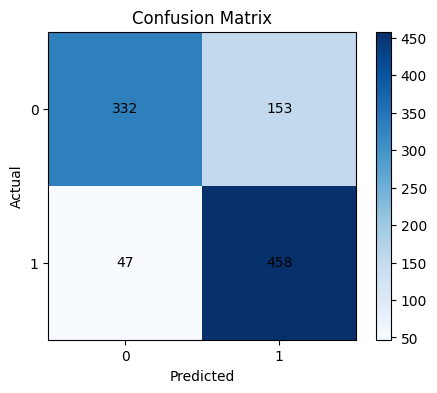

In [38]:
plt.figure(figsize=(5,4))
plt.imshow(scratch_cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
labels = ["0", "1"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)
for i in range(2):
    for j in range(2):
        plt.text(j, i, scratch_cm[i, j],
                 ha='center', va='center',
                 color='black')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM (using sklearn) for comparing

## Create the model

In [39]:
model = SVC(C=0.1,gamma=0.1, max_iter=300, tol=0.01)
model.fit(X_train, y_train) # training the model


c:\Users\HP Zbook G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=300).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.01
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Test accuracy

In [40]:
Train_predicted_sklearn = model.predict(X_train) 
Test_predicted_sklearn = model.predict(X_test) # making predictions

sklearn_acc_train = accuracy(y_train, Train_predicted_sklearn) 
sklearn_acc_test = accuracy(y_test, Test_predicted_sklearn) # calculating accuracy

print("sklearn tain accuracy: " + str(sklearn_acc_train * 100) + " %")
print("sklearn test accuracy: " + str(sklearn_acc_test * 100) + " %")
print("Training report:")
print(classification_report(y_train, Train_predicted_sklearn, target_names=["Legit (-1)", "Fraud (1)"]))
print("Test report:")
print(classification_report(y_test, Test_predicted_sklearn, target_names=["Legit (-1)", "Fraud (1)"]))

sklearn tain accuracy: 93.80844073793277 %
sklearn test accuracy: 92.62626262626263 %
Training report:
              precision    recall  f1-score   support

  Legit (-1)       0.97      0.91      0.94      2025
   Fraud (1)       0.91      0.97      0.94      1932

    accuracy                           0.94      3957
   macro avg       0.94      0.94      0.94      3957
weighted avg       0.94      0.94      0.94      3957

Test report:
              precision    recall  f1-score   support

  Legit (-1)       0.95      0.89      0.92       485
   Fraud (1)       0.90      0.96      0.93       505

    accuracy                           0.93       990
   macro avg       0.93      0.93      0.93       990
weighted avg       0.93      0.93      0.93       990



## confusion matrix

<Figure size 500x400 with 0 Axes>

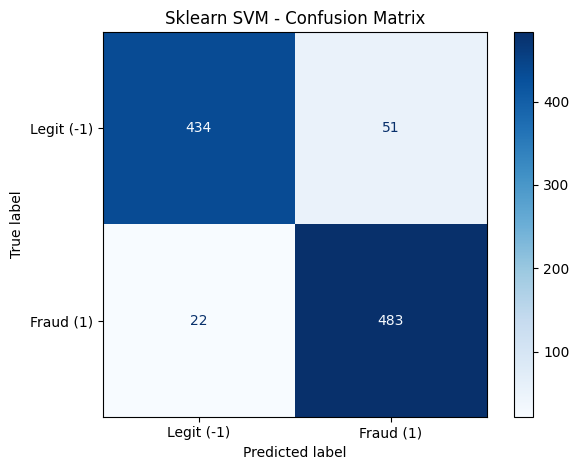

In [41]:
# Sklearn Confusion Matrix


sklearn_cm = confusion_matrix(y_test, Test_predicted_sklearn)

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(sklearn_cm, display_labels=["Legit (-1)", "Fraud (1)"]).plot(cmap="Blues")
plt.title("Sklearn SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

## Final Comparison Table

In [42]:
results = {
    "Accuracy":  [accuracy_score(y_test, test_pred),
                  accuracy_score(y_test, Test_predicted_sklearn)],
    "Precision": [precision_score(y_test, test_pred, pos_label=1),
                  precision_score(y_test, Test_predicted_sklearn, pos_label=1)],
    "Recall":    [recall_score(y_test, test_pred, pos_label=1),
                  recall_score(y_test, Test_predicted_sklearn, pos_label=1)],
    "F1 Score":  [f1_score(y_test, test_pred, pos_label=1),
                  f1_score(y_test, Test_predicted_sklearn, pos_label=1)],
}
df_results = pd.DataFrame(results, index=["Scratch SVM", "Sklearn SVM"])
print(df_results.round(4))

             Accuracy  Precision  Recall  F1 Score
Scratch SVM    0.7980     0.7496  0.9069    0.8208
Sklearn SVM    0.9263     0.9045  0.9564    0.9297
